# Лабораторная работа № 6.


Разработка имитационной модели одноканальной вычислительной системы с
одноместным накопителем.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [26]:
def exp_func(lmbd, p):
    return -1 / lmbd * np.log(p)

def generate_request_time_exp(lmbd, work_time):
    T_server = [0]
    while True:
        new_t = T_server[-1] + exp_func(lmbd, np.random.rand())
        if new_t > work_time:
            break
        T_server.append(new_t)
    T_server.pop(0)
    return np.asarray(T_server)

def generate_process_time_exp(lmbd, n):
    return exp_func(lmbd, np.random.rand(n))

def simulate(Ts, Tz):
    last_time = 0
    processed_signals = 0
    for i in range(len(Ts)):
        if last_time <= Ts[i]:
            last_time = Ts[i] + Tz[i]
            processed_signals += 1
    return processed_signals

def simulate_with_acc(Ts, Tz):
    last_time = 0
    pre_last_time = 0
    processed_signals = 0
    work_time = 0
    all_t_rej = []
    for i in range(len(Ts)):
        if last_time <= Ts[i]:
            all_t_rej.append(0)
            pre_last_time = last_time
            last_time = Ts[i] + Tz[i]
            processed_signals += 1
            work_time += Tz[i]
        elif pre_last_time <= Ts[i]:
            all_t_rej.append(last_time - Ts[i])
            pre_last_time = last_time
            last_time += Tz[i]
            processed_signals += 1
            work_time += Tz[i]
        else:
            all_t_rej.append(0)

    return processed_signals, work_time, all_t_rej

In [27]:
lmbd = 0.32
mu = 0.4
T = 1000

In [28]:
T_req = generate_request_time_exp(lmbd, T)
T_processing = generate_process_time_exp(mu, len(T_req))

processed_requests, work_t, all_t_rej = simulate_with_acc(T_req, T_processing)

print("============Симуляция============")
print(f"Число обработанных программ: {processed_requests}")
print(f"Число отказов: {len(T_req) - processed_requests}")
print(f"Общее число программ: {len(T_req)}")
print(f"Относительная пропускная способность: {processed_requests / len(T_req)}")
print(f"Время работы процессора: {work_t}")
print(f"Время простоя процессора: {T - work_t}")
print(f"Вероятность загрузки процессора: {work_t / T}")
print(f"Вероятность простоя процессора: {1 - (work_t / T)}")
print(f"Вероятность отказа в обслуживании: {np.sum(all_t_rej) / T}")
print(f"Абсолютная пропускная способность: {processed_requests / T}")
print(f"Коэфф. загрузки каналов: {work_t / T}")
print(f"Вероятность нахождения заявки в накопителе: {np.sum(all_t_rej) / T}")
print(f"Среднее число заявок в очереди: {np.sum(all_t_rej) / T}")
print(f"Среднее время ожидания в очереди: {np.mean(all_t_rej)}")

============Симуляция============
Число обработанных программ: 226
Число отказов: 86
Общее число программ: 312
Относительная пропускная способность: 0.7243589743589743
Время работы процессора: 578.262345123547
Время простоя процессора: 421.737654876453
Вероятность загрузки процессора: 0.578262345123547
Вероятность простоя процессора: 0.421737654876453
Вероятность отказа в обслуживании: 0.254701016198244
Абсолютная пропускная способность: 0.226
Коэфф. загрузки каналов: 0.578262345123547
Вероятность нахождения заявки в накопителе: 0.254701016198244
Среднее число заявок в очереди: 0.254701016198244
Среднее время ожидания в очереди: 0.8163494108918077


In [29]:
p = lmbd / mu
p_free = 1 / (1 + p + p**2)
p_rej = p**2 * p_free
Q = 1 - p_rej
A = Q * lmbd
k = A / mu
p_in_acc = p**2 * p_free
L = p**2 * p_free
mean_t_acc = L / lmbd
print("============Теория============")
print(f"Вероятность простоя процессора: {p_free}")
print(f"Вероятность отказа в обслуживании: {p_rej}")
print(f"Относительная пропускная способность: {Q}")
print(f"Абсолютная пропускная способность: {A}")
print(f"Коэфф. загрузки каналов: {k}")
print(f"Вероятность нахождения заявки в накопителе: {p_in_acc}")
print(f"Среднее число заявок в очереди: {L}")
print(f"Среднее время ожидания в очереди: {mean_t_acc}")

============Теория============
Вероятность простоя процессора: 0.40983606557377056
Вероятность отказа в обслуживании: 0.26229508196721313
Относительная пропускная способность: 0.7377049180327868
Абсолютная пропускная способность: 0.23606557377049178
Коэфф. загрузки каналов: 0.5901639344262294
Вероятность нахождения заявки в накопителе: 0.26229508196721313
Среднее число заявок в очереди: 0.26229508196721313
Среднее время ожидания в очереди: 0.819672131147541


Задание Nº3.
Для разработанной имитационной модели ВС провести ее тестирование путем сопоставления выходных значений, полученных с помощью компьютерной программы, разработанной в результате выполнения задания Nº2 и значений, полученных в результате выполнения задания Nº1.

In [30]:
# Сравнение теории и симуляции для первого запуска
sim_vals = {
    'Вероятность простоя процессора':      1 - (work_t / T),
    'Вероятность отказа в обслуживании':   np.sum(all_t_rej) / T,
    'Относительная пропускная способность': processed_requests / len(T_req),
    'Абсолютная пропускная способность':   processed_requests / T,
    'Коэфф. загрузки каналов':             work_t / T,
    'Вероятность нахождения заявки в накопителе': np.sum(all_t_rej) / T,
    'Среднее число заявок в очереди':      np.sum(all_t_rej) / T,
    'Среднее время ожидания в очереди':    np.mean(all_t_rej),
}

theor_vals = {
    'Вероятность простоя процессора':      p_free,
    'Вероятность отказа в обслуживании':   p_rej,
    'Относительная пропускная способность': Q,
    'Абсолютная пропускная способность':   A,
    'Коэфф. загрузки каналов':             k,
    'Вероятность нахождения заявки в накопителе': p_in_acc,
    'Среднее число заявок в очереди':      L,
    'Среднее время ожидания в очереди':    mean_t_acc,
}

df_compare = pd.DataFrame({
    'Симуляция': sim_vals,
    'Теория':    theor_vals,
})
df_compare['Отклонение, %'] = ((df_compare['Симуляция'] - df_compare['Теория']) / df_compare['Теория'] * 100).round(2)
df_compare = df_compare.round(6)

display(df_compare)

,Симуляция,Теория,"Отклонение, %"
Вероятность простоя процессора,0.421738,0.409836,2.90
Вероятность отказа в обслуживании,0.254701,0.262295,-2.90
Относительная пропускная способность,0.724359,0.737705,-1.81
Абсолютная пропускная способность,0.226000,0.236066,-4.26
Коэфф. загрузки каналов,0.578262,0.590164,-2.02
Вероятность нахождения заявки в накопителе,0.254701,0.262295,-2.90
Среднее число заявок в очереди,0.254701,0.262295,-2.90
Среднее время ожидания в очереди,0.816349,0.819672,-0.41


Задание Nº4.
Провести анализ работы заданной структуры ИС в виде выходных характеристик имитационной модели ИС - относительной пропускной способности ИС и загрузки процессора в зависимости от коэффициента загрузки - p = Lmd/mu. Сопоставить эти значения с аналитическими, полученными для одноканальной ИС с накопителем на основе теории массового облуживания.

In [31]:
mu4 = 1
ros4 = np.linspace(0.1, 1, 1000)[:-1]
T = 1000

Z = []
Z1 = []
for ro in ros4:
    lmbd4 = ro * mu4
    T_req = generate_request_time_exp(lmbd4, T)
    T_processing = generate_process_time_exp(mu4, len(T_req))

    processed_requests, work_t, all_t_rej = simulate_with_acc(T_req, T_processing)
    Z.append(processed_requests / len(T_req))
    Z1.append(work_t / T)

Pobr = (1 + ros4) / (1 + ros4 + ros4**2)
Ps = ros4 * (1 - ros4**2) / (1 - ros4**3)


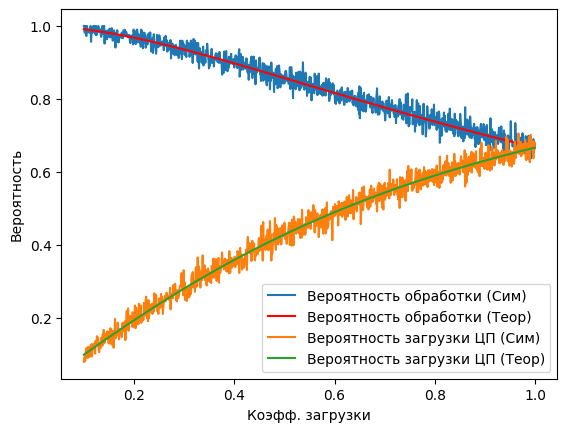

In [32]:
plt.plot(ros4, Z, label='Вероятность обработки (Сим)')
plt.plot(ros4, Pobr, color='red', label='Вероятность обработки (Теор)')
plt.plot(ros4, Z1, label='Вероятность загрузки ЦП (Сим)')
plt.plot(ros4, Ps, label='Вероятность загрузки ЦП (Теор)')
plt.xlabel("Коэфф. загрузки")
plt.ylabel("Вероятность")
plt.legend()
plt.show()

Задание Nº5.
Провести сопоставление эффективности работы двух систем одноканальной с отказами (см. Лабораторную работу Nº4) и одноканальной с одноместным накопителем. В качестве критерия оценки эффективности использовать «Относительную пропускную способность ВС».

In [33]:
mu4 = 1
ros4 = np.linspace(0.1, 1, 1000)[:-1]
T = 1000

Q_acc = []
Q_clear = []
for ro in ros4:
    lmbd4 = ro * mu4
    T_req = generate_request_time_exp(lmbd4, T)
    T_processing = generate_process_time_exp(mu4, len(T_req))

    processed_requests, work_t, all_t_rej = simulate_with_acc(T_req, T_processing)
    Q_acc.append(processed_requests / len(T_req))

    processed_requests_clear = simulate(T_req, T_processing)
    Q_clear.append(processed_requests_clear / len(T_req))


Q_acc_theor = (1 - ros4**2) / (1 - ros4**3)
Q_clear_theor = 1 / (1 + ros4)


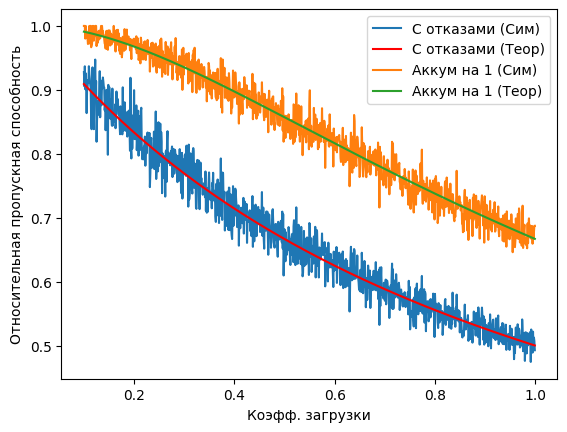

In [34]:
plt.plot(ros4, Q_clear, label='С отказами (Сим)')
plt.plot(ros4, Q_clear_theor, color='red', label='С отказами (Теор)')
plt.plot(ros4, Q_acc, label='Аккум на 1 (Сим)')
plt.plot(ros4, Q_acc_theor, label='Аккум на 1 (Теор)')
plt.xlabel("Коэфф. загрузки")
plt.ylabel("Относительная пропускная способность")
plt.legend()
plt.show()

Задание Nº6.
Провести сопоставление эффективности работы двух систем: одноканальной с отказами (см. Лабораторную работу Nº4) и одноканальной с одноместным накопителем. В качестве критерия оценки эффективности использовать критерий, приведенный выше - стоимость получения прибыли от работы информационной системы.
Сопоставить полученные значения стоимости Е в зависимости от интенсивности
входного потока - (lambda).

In [35]:
mu4 = 1
ros4 = np.linspace(0.1, 1, 1000)[:-1]
T = 1000

c1 = 1
qf = 0.15
qr = 0.01

E_acc = []
E_clear = []
# Pf_acc = []
# Pf_clear = []
for ro in ros4:
    lmbd4 = ro * mu4
    T_req = generate_request_time_exp(lmbd4, T)
    T_processing = generate_process_time_exp(mu4, len(T_req))

    processed_requests, work_t, all_t_rej = simulate_with_acc(T_req, T_processing)
    E_acc.append(processed_requests * c1 - (len(T_req) - processed_requests) * qf - np.mean(all_t_rej) * qr)

    processed_requests_clear = simulate(T_req, T_processing)
    E_clear.append(processed_requests_clear * c1 - (len(T_req) - processed_requests) * qf)

lmbds = ros4 * mu4

tr = ros4**2 / (1 + ros4 + ros4**2) / lmbds


Pf_acc = ros4**2 * (1 / (1 + ros4 + ros4**2))
Pf_clear = ros4 * (1 / (1 + ros4))

E_acc_theor = ((1 - ros4**2) / (1 - ros4**3)) * 0.5 * c1 - qf * (1 - (1 - ros4**2) / (1 - ros4**3)) * 0.5 - qr * ros4**2 / ((1 + ros4 + ros4**2) * 0.5)
E_clear_theor = (1 - ros4 / (1 + ros4)) * 0.5 * c1 - qf * (ros4 / (1 + ros4)) * 0.5


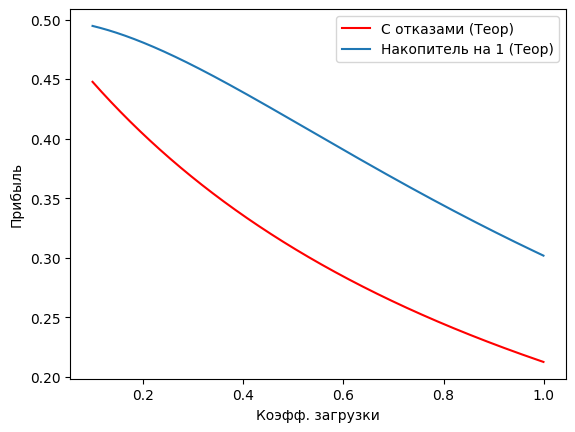

In [36]:
plt.plot(ros4, E_clear_theor, color='red', label='С отказами (Теор)')
plt.plot(ros4, E_acc_theor, label='Накопитель на 1 (Теор)')
plt.xlabel("Коэфф. загрузки")
plt.ylabel("Прибыль")
plt.legend()
plt.show()